In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install lightgbm joblib

In [ ]:
import os
import re
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

In [ ]:

RANDOM_STATE = 42

EXPERIMENT_NAME = "tfidf_stack_meta_lr_class_weight_tuning_v1"

BASE_DIR = "/content/drive/MyDrive/CS114/TeamModel"
DATA_DIR = os.path.join(BASE_DIR, "data")

TRAIN_PATH = os.path.join(DATA_DIR, "train_clean_tokenizedEmoji.csv")
VAL_PATH = os.path.join(DATA_DIR, "val_clean_tokenizedEmoji.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_clean_tokenizedEmoji.csv")

ARTIFACT_ROOT = os.path.join(BASE_DIR, "experiments", EXPERIMENT_NAME)
CHECKPOINT_DIR = os.path.join(ARTIFACT_ROOT, "checkpoints")
REPORT_DIR = os.path.join(ARTIFACT_ROOT, "reports")
ERROR_DIR = os.path.join(ARTIFACT_ROOT, "errors")
FIGURE_DIR = os.path.join(ARTIFACT_ROOT, "figures")

for d in [ARTIFACT_ROOT, CHECKPOINT_DIR, REPORT_DIR, ERROR_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

N_SPLITS = 3
DROP_CROSS_SPLIT_DUPLICATES = True

FEATURE_K = 35000

WORD_NGRAM_RANGE = (1, 3)
CHAR_ANALYZER = "char_wb"
CHAR_NGRAM_RANGE = (3, 5)

WORD_MAX_FEATURES = 30000
CHAR_MAX_FEATURES = 30000
WORD_MIN_DF = 3
CHAR_MIN_DF = 3

FORCE_TRAIN = False
FORCE_META_TUNE = False

SVM_C = 0.8
CNB_ALPHA = 0.1

LGB_N_ESTIMATORS = 300
LGB_LEARNING_RATE = 0.05
LGB_NUM_LEAVES = 31

META_C = 1.0

OOF_TRAIN_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_train.npy")
OOF_VAL_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_val.npy")
OOF_TEST_PATH = os.path.join(CHECKPOINT_DIR, f"{EXPERIMENT_NAME}__oof_test.npy")

FOLD_BUNDLE_PATHS = [
    os.path.join(
        CHECKPOINT_DIR,
        f"{EXPERIMENT_NAME}__fold_{fold_idx}_bundle.joblib"
    )
    for fold_idx in range(1, N_SPLITS + 1)
]

META_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__meta_logistic_model.joblib"
)

WEIGHTS_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__class_decision_weights.json"
)

CONFIG_PATH = os.path.join(
    CHECKPOINT_DIR,
    f"{EXPERIMENT_NAME}__config.json"
)

config = {
    "EXPERIMENT_NAME": EXPERIMENT_NAME,
    "N_SPLITS": N_SPLITS,
    "DROP_CROSS_SPLIT_DUPLICATES": DROP_CROSS_SPLIT_DUPLICATES,
    "FEATURE_K": FEATURE_K,
    "WORD_NGRAM_RANGE": WORD_NGRAM_RANGE,
    "CHAR_ANALYZER": CHAR_ANALYZER,
    "CHAR_NGRAM_RANGE": CHAR_NGRAM_RANGE,
    "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
    "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
    "WORD_MIN_DF": WORD_MIN_DF,
    "CHAR_MIN_DF": CHAR_MIN_DF,
    "SVM_C": SVM_C,
    "CNB_ALPHA": CNB_ALPHA,
    "LGB_N_ESTIMATORS": LGB_N_ESTIMATORS,
    "LGB_LEARNING_RATE": LGB_LEARNING_RATE,
    "LGB_NUM_LEAVES": LGB_NUM_LEAVES,
    "META_C": META_C,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Experiment:", EXPERIMENT_NAME)
print("Artifact root:", ARTIFACT_ROOT)
print(json.dumps(config, indent=2, ensure_ascii=False))

Experiment: tfidf_stack_meta_lr_class_weight_tuning_v1
Artifact root: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1
{
  "EXPERIMENT_NAME": "tfidf_stack_meta_lr_class_weight_tuning_v1",
  "N_SPLITS": 3,
  "DROP_CROSS_SPLIT_DUPLICATES": true,
  "FEATURE_K": 35000,
  "WORD_NGRAM_RANGE": [
    1,
    3
  ],
  "CHAR_ANALYZER": "char_wb",
  "CHAR_NGRAM_RANGE": [
    3,
    5
  ],
  "WORD_MAX_FEATURES": 30000,
  "CHAR_MAX_FEATURES": 30000,
  "WORD_MIN_DF": 3,
  "CHAR_MIN_DF": 3,
  "SVM_C": 0.8,
  "CNB_ALPHA": 0.1,
  "LGB_N_ESTIMATORS": 300,
  "LGB_LEARNING_RATE": 0.05,
  "LGB_NUM_LEAVES": 31,
  "META_C": 1.0
}


In [ ]:
def load_split(path):
    df = pd.read_csv(path)
    df = df.dropna(subset=["text", "status"]).copy()
    df["text"] = df["text"].astype(str)
    df["status"] = df["status"].astype(str).str.strip().str.lower()
    return df


train_raw = load_split(TRAIN_PATH)
val_raw = load_split(VAL_PATH)
test_raw = load_split(TEST_PATH)

print("Before duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

print("\nTrain labels:")
print(train_raw["status"].value_counts())

print("\nVal labels:")
print(val_raw["status"].value_counts())

print("\nTest labels:")
print(test_raw["status"].value_counts())

Before duplicate/overlap handling:
Train: (34601, 2)
Val:   (4943, 2)
Test:  (9887, 2)

Train labels:
status
normal        12706
depression    10154
suicidal       7840
anxiety        3901
Name: count, dtype: int64

Val labels:
status
normal        1815
depression    1451
suicidal      1120
anxiety        557
Name: count, dtype: int64

Test labels:
status
normal        3630
depression    2902
suicidal      2240
anxiety       1115
Name: count, dtype: int64


In [ ]:
def normalize_text_key(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


for df in [train_raw, val_raw, test_raw]:
    df["text_key"] = df["text"].apply(normalize_text_key)


if DROP_CROSS_SPLIT_DUPLICATES:
    train_keys = set(train_raw["text_key"])

    before_val = len(val_raw)
    val_raw = val_raw[~val_raw["text_key"].isin(train_keys)].copy()
    after_val = len(val_raw)

    train_val_keys = set(train_raw["text_key"]) | set(val_raw["text_key"])

    before_test = len(test_raw)
    test_raw = test_raw[~test_raw["text_key"].isin(train_val_keys)].copy()
    after_test = len(test_raw)

    print("Removed from val due to train overlap:", before_val - after_val)
    print("Removed from test due to train/val overlap:", before_test - after_test)


train_raw = train_raw.drop(columns=["text_key"])
val_raw = val_raw.drop(columns=["text_key"])
test_raw = test_raw.drop(columns=["text_key"])

print("\nAfter duplicate/overlap handling:")
print("Train:", train_raw.shape)
print("Val:  ", val_raw.shape)
print("Test: ", test_raw.shape)

Removed from val due to train overlap: 4
Removed from test due to train/val overlap: 12

After duplicate/overlap handling:
Train: (34601, 2)
Val:   (4939, 2)
Test:  (9875, 2)


In [ ]:
def extract_advanced_features(df):
    df_out = df.copy()
    raw_text = df_out["text"].astype(str)

    df_out["cleaned_text"] = raw_text.str.lower().str.strip()

    # Rút gọn ký tự lặp cực dài
    df_out["cleaned_text"] = df_out["cleaned_text"].apply(
        lambda x: re.sub(r"(.)\1{4,}", r"\1\1", x)
    )

    df_out["char_len"] = raw_text.str.len()

    df_out["word_count"] = raw_text.apply(
        lambda x: len(str(x).split())
    )

    df_out["avg_word_len"] = df_out["char_len"] / (df_out["word_count"] + 1e-5)

    df_out["uppercase_ratio"] = raw_text.apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1e-5)
    )

    df_out["i_pronoun_ratio"] = df_out["cleaned_text"].apply(
        lambda x: len(re.findall(r"\b(i|me|my|myself|mine)\b", x))
        / (len(x.split()) + 1e-5)
    )

    df_out["negation_ratio"] = df_out["cleaned_text"].apply(
        lambda x: len(re.findall(r"\b(no|not|never|nothing|none|cannot|dont|don't|cant|can't)\b", x))
        / (len(x.split()) + 1e-5)
    )

    df_out["ellipsis_count"] = raw_text.apply(
        lambda x: len(re.findall(r"\.\.\.", str(x)))
    )

    df_out["exclamation_count"] = raw_text.apply(
        lambda x: str(x).count("!")
    )

    df_out["question_count"] = raw_text.apply(
        lambda x: str(x).count("?")
    )

    df_out["suicide_keyword_count"] = df_out["cleaned_text"].apply(
        lambda x: len(
            re.findall(
                r"\b(suicide|suicidal|kill myself|kms|kys|end my life|want to die|wanna die|die|overdose|hang myself)\b",
                x
            )
        )
    )

    return df_out


train_enriched = extract_advanced_features(train_raw)
val_enriched = extract_advanced_features(val_raw)
test_enriched = extract_advanced_features(test_raw)

y_train = train_enriched["status"].values
y_val = val_enriched["status"].values
y_test = test_enriched["status"].values

class_names = np.array(sorted(train_enriched["status"].unique()))

print("Classes:", class_names)
print("Train enriched:", train_enriched.shape)
print("Val enriched:  ", val_enriched.shape)
print("Test enriched: ", test_enriched.shape)

display(train_enriched.head())

Classes: ['anxiety' 'depression' 'normal' 'suicidal']
Train enriched: (34601, 13)
Val enriched:   (4939, 13)
Test enriched:  (9875, 13)


,text,status,cleaned_text,char_len,word_count,avg_word_len,uppercase_ratio,i_pronoun_ratio,negation_ratio,ellipsis_count,exclamation_count,question_count,suicide_keyword_count
0,is anime bad ? is anime bad ? i think it's bad...,normal,is anime bad ? is anime bad ? i think it's bad...,124,31,3.999999,0.0,0.096774,0.000000,0,0,2,0
1,horror wench me too i feel like i ve been on t...,normal,horror wench me too i feel like i ve been on t...,83,19,4.368419,0.0,0.157895,0.000000,0,0,0,0
2,context: my father-in-law is/was the ultimate ...,normal,context: my father-in-law is/was the ultimate ...,527,89,5.921348,0.0,0.022472,0.000000,0,0,0,0
3,been trying the whole online dating thing have...,suicidal,been trying the whole online dating thing have...,363,76,4.776315,0.0,0.118421,0.052632,0,0,0,0
4,"selling passive caucasian instagram followers,...",normal,"selling passive caucasian instagram followers,...",150,28,5.357141,0.0,0.000000,0.000000,0,2,0,0


In [ ]:
def build_preprocessor():
    text_features = FeatureUnion([
        ("word_ngram", TfidfVectorizer(
            analyzer="word",
            ngram_range=WORD_NGRAM_RANGE,
            min_df=WORD_MIN_DF,
            max_df=0.90,
            max_features=WORD_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        )),
        ("char_ngram", TfidfVectorizer(
            analyzer=CHAR_ANALYZER,
            ngram_range=CHAR_NGRAM_RANGE,
            min_df=CHAR_MIN_DF,
            max_features=CHAR_MAX_FEATURES,
            sublinear_tf=True,
            dtype=np.float32
        ))
    ])

    numeric_features = Pipeline([
        ("scaler", MinMaxScaler())
    ])

    return ColumnTransformer(transformers=[
        ("text", text_features, "cleaned_text"),
        ("num", numeric_features, [
            "word_count",
            "char_len",
            "avg_word_len",
            "uppercase_ratio",
            "i_pronoun_ratio",
            "negation_ratio",
            "ellipsis_count",
            "exclamation_count",
            "question_count",
            "suicide_keyword_count"
        ])
    ])


def fit_transform_features_no_leakage(X_tr, y_tr, X_va, X_external_list=None):
    if X_external_list is None:
        X_external_list = []

    preprocessor = build_preprocessor()

    X_tr_pre = preprocessor.fit_transform(X_tr)
    X_va_pre = preprocessor.transform(X_va)

    k_eff = min(FEATURE_K, X_tr_pre.shape[1])

    selector = SelectKBest(score_func=chi2, k=k_eff)

    X_tr_fe = selector.fit_transform(X_tr_pre, y_tr)
    X_va_fe = selector.transform(X_va_pre)

    X_external_fe = []

    for X_ext in X_external_list:
        X_ext_pre = preprocessor.transform(X_ext)
        X_external_fe.append(selector.transform(X_ext_pre))

    feature_pipeline = {
        "preprocessor": preprocessor,
        "selector": selector
    }

    return X_tr_fe, X_va_fe, X_external_fe, feature_pipeline


def aligned_predict_proba(model, X, target_classes):
    proba = model.predict_proba(X)

    aligned = np.zeros(
        (X.shape[0], len(target_classes)),
        dtype=np.float32
    )

    for src_idx, cls in enumerate(model.classes_):
        dst_idx = np.where(target_classes == cls)[0][0]
        aligned[:, dst_idx] = proba[:, src_idx]

    return aligned


def make_base_models():
    svm = CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            C=SVM_C,
            dual=False,
            random_state=RANDOM_STATE
        ),
        cv=3
    )

    cnb = ComplementNB(
        alpha=CNB_ALPHA,
        norm=True
    )

    lgb = LGBMClassifier(
        class_weight="balanced",
        n_estimators=LGB_N_ESTIMATORS,
        learning_rate=LGB_LEARNING_RATE,
        num_leaves=LGB_NUM_LEAVES,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    return {
        "svm": svm,
        "cnb": cnb,
        "lgb": lgb
    }


base_model_names = ["svm", "cnb", "lgb"]

print("Base models:", base_model_names)
print("WORD_NGRAM_RANGE:", WORD_NGRAM_RANGE)
print("CHAR_ANALYZER:", CHAR_ANALYZER)
print("CHAR_NGRAM_RANGE:", CHAR_NGRAM_RANGE)
print("FEATURE_K:", FEATURE_K)
print("SVM_C:", SVM_C)
print("CNB_ALPHA:", CNB_ALPHA)
print("LGB:", LGB_N_ESTIMATORS, LGB_LEARNING_RATE, LGB_NUM_LEAVES)

Base models: ['svm', 'cnb', 'lgb']
WORD_NGRAM_RANGE: (1, 3)
CHAR_ANALYZER: char_wb
CHAR_NGRAM_RANGE: (3, 5)
FEATURE_K: 35000
SVM_C: 0.8
CNB_ALPHA: 0.1
LGB: 300 0.05 31


In [ ]:
checkpoint_ready = (
    os.path.exists(OOF_TRAIN_PATH)
    and os.path.exists(OOF_VAL_PATH)
    and os.path.exists(OOF_TEST_PATH)
    and all(os.path.exists(p) for p in FOLD_BUNDLE_PATHS)
)

if (not FORCE_TRAIN) and checkpoint_ready:
    print("Found existing checkpoints. Loading OOF features and fold bundles...")

    oof_train = np.load(OOF_TRAIN_PATH)
    oof_val = np.load(OOF_VAL_PATH)
    oof_test = np.load(OOF_TEST_PATH)

    fold_bundles = [
        joblib.load(p)
        for p in FOLD_BUNDLE_PATHS
    ]

    print("Loaded existing checkpoints.")
    print("oof_train:", oof_train.shape)
    print("oof_val:  ", oof_val.shape)
    print("oof_test: ", oof_test.shape)
    print("fold_bundles:", len(fold_bundles))

else:
    print("No usable checkpoints found, or FORCE_TRAIN=True.")
    print("Training base models and creating OOF features...")

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    n_classes = len(class_names)
    n_base_models = len(base_model_names)
    n_meta_features = n_classes * n_base_models

    oof_train = np.zeros(
        (len(train_enriched), n_meta_features),
        dtype=np.float32
    )

    val_fold_features = []
    test_fold_features = []

    fold_bundles = []

    for fold_idx, (tr_idx, holdout_idx) in enumerate(
        skf.split(train_enriched, y_train),
        start=1
    ):
        print(f"\n================ FOLD {fold_idx}/{N_SPLITS} ================")

        X_tr = train_enriched.iloc[tr_idx]
        y_tr = y_train[tr_idx]

        X_holdout = train_enriched.iloc[holdout_idx]
        y_holdout = y_train[holdout_idx]

        X_tr_fe, X_holdout_fe, external_fe, feature_pipeline = fit_transform_features_no_leakage(
            X_tr=X_tr,
            y_tr=y_tr,
            X_va=X_holdout,
            X_external_list=[val_enriched, test_enriched]
        )

        X_val_fe, X_test_fe = external_fe

        models = make_base_models()

        holdout_meta_parts = []
        val_meta_parts = []
        test_meta_parts = []

        for model_name in base_model_names:
            print(f"Training {model_name}...")

            model = models[model_name]
            model.fit(X_tr_fe, y_tr)

            holdout_proba = aligned_predict_proba(
                model,
                X_holdout_fe,
                class_names
            )

            val_proba = aligned_predict_proba(
                model,
                X_val_fe,
                class_names
            )

            test_proba = aligned_predict_proba(
                model,
                X_test_fe,
                class_names
            )

            holdout_meta_parts.append(holdout_proba)
            val_meta_parts.append(val_proba)
            test_meta_parts.append(test_proba)

        holdout_meta = np.hstack(holdout_meta_parts)
        val_meta = np.hstack(val_meta_parts)
        test_meta = np.hstack(test_meta_parts)

        oof_train[holdout_idx] = holdout_meta

        val_fold_features.append(val_meta)
        test_fold_features.append(test_meta)

        fold_bundle = {
            "feature_pipeline": feature_pipeline,
            "models": models,
            "class_names": class_names
        }

        fold_path = os.path.join(
            CHECKPOINT_DIR,
            f"{EXPERIMENT_NAME}__fold_{fold_idx}_bundle.joblib"
        )

        joblib.dump(fold_bundle, fold_path)
        fold_bundles.append(fold_bundle)

        print("Saved fold bundle:", fold_path)

    oof_val = np.mean(val_fold_features, axis=0)
    oof_test = np.mean(test_fold_features, axis=0)

    np.save(OOF_TRAIN_PATH, oof_train)
    np.save(OOF_VAL_PATH, oof_val)
    np.save(OOF_TEST_PATH, oof_test)

    print("\nSaved OOF features:")
    print(OOF_TRAIN_PATH)
    print(OOF_VAL_PATH)
    print(OOF_TEST_PATH)

    print("\nOOF shapes:")
    print("oof_train:", oof_train.shape)
    print("oof_val:  ", oof_val.shape)
    print("oof_test: ", oof_test.shape)

No usable checkpoints found, or FORCE_TRAIN=True.
Training base models and creating OOF features...

================ FOLD 1/3 ================
Training svm...
Training cnb...
Training lgb...
Saved fold bundle: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/checkpoints/tfidf_stack_meta_lr_class_weight_tuning_v1__fold_1_bundle.joblib

================ FOLD 2/3 ================
Training svm...
Training cnb...
Training lgb...
Saved fold bundle: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/checkpoints/tfidf_stack_meta_lr_class_weight_tuning_v1__fold_2_bundle.joblib

================ FOLD 3/3 ================
Training svm...
Training cnb...
Training lgb...
Saved fold bundle: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/checkpoints/tfidf_stack_meta_lr_class_weight_tuning_v1__fold_3_bundle.joblib

Saved OOF features:
/content/drive/MyDrive/CS114/Team

In [ ]:
META_TUNING_RESULT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__meta_class_weight_tuning.csv"
)

BEST_DECISION_GRID_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__best_meta_decision_weight_grid.csv"
)

META_CLASS_WEIGHT_CONFIGS = [
    {
        "name": "meta_balanced",
        "class_weight": "balanced"
    },
    {
        "name": "meta_dep_sui_light",
        "class_weight": {
            "anxiety": 1.00,
            "depression": 1.10,
            "normal": 0.95,
            "suicidal": 1.10
        }
    },
    {
        "name": "meta_dep_sui_mid",
        "class_weight": {
            "anxiety": 1.00,
            "depression": 1.15,
            "normal": 0.90,
            "suicidal": 1.15
        }
    },
    {
        "name": "meta_dep_sui_strong",
        "class_weight": {
            "anxiety": 1.00,
            "depression": 1.20,
            "normal": 0.85,
            "suicidal": 1.20
        }
    },
    {
        "name": "meta_dep_more",
        "class_weight": {
            "anxiety": 1.00,
            "depression": 1.25,
            "normal": 0.90,
            "suicidal": 1.10
        }
    },
    {
        "name": "meta_sui_more",
        "class_weight": {
            "anxiety": 1.00,
            "depression": 1.10,
            "normal": 0.90,
            "suicidal": 1.25
        }
    },
    {
        "name": "meta_normal_down",
        "class_weight": {
            "anxiety": 1.00,
            "depression": 1.15,
            "normal": 0.80,
            "suicidal": 1.15
        }
    },
]


def predict_with_weights(probabilities, weights, classes):
    return np.array(classes)[np.argmax(probabilities * weights, axis=1)]


def tune_decision_weights_on_val(proba_val, y_val, class_list):
    base_weights = np.ones(len(class_list), dtype=np.float32)
    idx = {cls: i for i, cls in enumerate(class_list)}

    anxiety_grid = [1.00]
    depression_grid = [1.10, 1.20, 1.30, 1.40, 1.50]
    normal_grid = [0.90, 1.00]
    suicidal_grid = [1.00, 1.10, 1.15, 1.20, 1.30]

    best_score = -1
    best_weights = base_weights.copy()
    records = []

    for anxiety_w in anxiety_grid:
        for normal_w in normal_grid:
            for dep_w in depression_grid:
                for sui_w in suicidal_grid:
                    weights = base_weights.copy()

                    if "anxiety" in idx:
                        weights[idx["anxiety"]] = anxiety_w

                    if "depression" in idx:
                        weights[idx["depression"]] = dep_w

                    if "normal" in idx:
                        weights[idx["normal"]] = normal_w

                    if "suicidal" in idx:
                        weights[idx["suicidal"]] = sui_w

                    preds_val = predict_with_weights(
                        proba_val,
                        weights,
                        class_list
                    )

                    macro_f1 = f1_score(
                        y_val,
                        preds_val,
                        average="macro"
                    )

                    records.append({
                        "anxiety_weight": anxiety_w,
                        "depression_weight": dep_w,
                        "normal_weight": normal_w,
                        "suicidal_weight": sui_w,
                        "val_macro_f1": macro_f1
                    })

                    if macro_f1 > best_score:
                        best_score = macro_f1
                        best_weights = weights.copy()

    weight_dict = {
        cls: float(best_weights[i])
        for i, cls in enumerate(class_list)
    }

    grid_df = pd.DataFrame(records).sort_values(
        "val_macro_f1",
        ascending=False
    )

    return best_score, best_weights, weight_dict, grid_df


def get_per_class_f1(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    return {
        f"f1_{label}": report[label]["f1-score"]
        for label in labels
    }


meta_checkpoint_ready = (
    os.path.exists(META_MODEL_PATH)
    and os.path.exists(WEIGHTS_PATH)
)

if (not FORCE_META_TUNE) and meta_checkpoint_ready:
    print("Found existing meta model and decision weights.")
    print("Loading saved meta LR...")

    meta_model = joblib.load(META_MODEL_PATH)

    with open(WEIGHTS_PATH, "r", encoding="utf-8") as f:
        weights_json = json.load(f)

    class_list = meta_model.classes_

    weight_dict = weights_json["weights"]

    best_weights = np.array(
        [weight_dict[cls] for cls in class_list],
        dtype=np.float32
    )

    best_meta_config_name = weights_json.get(
        "best_meta_config_name",
        "loaded_meta_model"
    )

    best_meta_class_weight = weights_json.get(
        "best_meta_class_weight",
        str(meta_model.class_weight)
    )

    proba_train = meta_model.predict_proba(oof_train)
    proba_val = meta_model.predict_proba(oof_val)
    proba_test = meta_model.predict_proba(oof_test)

    preds_train_final = predict_with_weights(
        proba_train,
        best_weights,
        class_list
    )

    preds_val_final = predict_with_weights(
        proba_val,
        best_weights,
        class_list
    )

    f1_train = f1_score(
        y_train,
        preds_train_final,
        average="macro"
    )

    f1_val = f1_score(
        y_val,
        preds_val_final,
        average="macro"
    )

    acc_train = accuracy_score(
        y_train,
        preds_train_final
    )

    acc_val = accuracy_score(
        y_val,
        preds_val_final
    )

    best_candidate = {
        "meta_model": meta_model,
        "class_list": class_list,
        "proba_train": proba_train,
        "proba_val": proba_val,
        "proba_test": proba_test,
        "best_weights": best_weights,
        "weight_dict": weight_dict,
        "preds_train": preds_train_final,
        "preds_val": preds_val_final,
        "train_macro_f1": f1_train,
        "val_macro_f1": f1_val,
        "train_accuracy": acc_train,
        "val_accuracy": acc_val,
        "meta_class_weight": best_meta_class_weight,
    }

    print("Loaded meta model:", META_MODEL_PATH)
    print("Loaded decision weights:", WEIGHTS_PATH)
    print("Best meta config:", best_meta_config_name)
    print("Weights:", weight_dict)
    print(f"OOF Train Macro F1: {f1_train:.4f}")
    print(f"Val Macro F1:       {f1_val:.4f}")


else:
    print("No usable meta checkpoint found, or FORCE_META_TUNE=True.")
    print("Tuning meta Logistic Regression class_weight...")

    meta_tuning_records = []
    meta_candidates = {}

    for cfg in META_CLASS_WEIGHT_CONFIGS:
        cfg_name = cfg["name"]
        cfg_class_weight = cfg["class_weight"]

        print("\n" + "=" * 80)
        print("Training meta LR config:", cfg_name)
        print("class_weight:", cfg_class_weight)
        print("=" * 80)

        meta_model_candidate = LogisticRegression(
            class_weight=cfg_class_weight,
            C=META_C,
            max_iter=3000,
            random_state=RANDOM_STATE
        )

        meta_model_candidate.fit(oof_train, y_train)

        proba_train_candidate = meta_model_candidate.predict_proba(oof_train)
        proba_val_candidate = meta_model_candidate.predict_proba(oof_val)
        proba_test_candidate = meta_model_candidate.predict_proba(oof_test)

        class_list_candidate = meta_model_candidate.classes_

        best_val_weight_score, best_weights_candidate, weight_dict_candidate, grid_df_candidate = (
            tune_decision_weights_on_val(
                proba_val_candidate,
                y_val,
                class_list_candidate
            )
        )

        preds_train_candidate = predict_with_weights(
            proba_train_candidate,
            best_weights_candidate,
            class_list_candidate
        )

        preds_val_candidate = predict_with_weights(
            proba_val_candidate,
            best_weights_candidate,
            class_list_candidate
        )

        train_macro_f1 = f1_score(
            y_train,
            preds_train_candidate,
            average="macro"
        )

        val_macro_f1 = f1_score(
            y_val,
            preds_val_candidate,
            average="macro"
        )

        train_acc = accuracy_score(
            y_train,
            preds_train_candidate
        )

        val_acc = accuracy_score(
            y_val,
            preds_val_candidate
        )

        per_class_val_f1 = get_per_class_f1(
            y_val,
            preds_val_candidate,
            class_list_candidate
        )

        print("Val Macro F1:", val_macro_f1)
        print("Best decision weights:", weight_dict_candidate)

        record = {
            "meta_config_name": cfg_name,
            "meta_class_weight": str(cfg_class_weight),
            "oof_train_macro_f1": train_macro_f1,
            "val_macro_f1": val_macro_f1,
            "oof_train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "gap_train_val": train_macro_f1 - val_macro_f1,
            "best_decision_weights": json.dumps(weight_dict_candidate),
        }

        record.update(per_class_val_f1)
        meta_tuning_records.append(record)

        meta_candidates[cfg_name] = {
            "meta_model": meta_model_candidate,
            "class_list": class_list_candidate,
            "proba_train": proba_train_candidate,
            "proba_val": proba_val_candidate,
            "proba_test": proba_test_candidate,
            "best_weights": best_weights_candidate,
            "weight_dict": weight_dict_candidate,
            "decision_grid_df": grid_df_candidate,
            "preds_train": preds_train_candidate,
            "preds_val": preds_val_candidate,
            "train_macro_f1": train_macro_f1,
            "val_macro_f1": val_macro_f1,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "meta_class_weight": cfg_class_weight,
        }

    meta_tuning_df = pd.DataFrame(meta_tuning_records).sort_values(
        "val_macro_f1",
        ascending=False
    )

    display(meta_tuning_df)

    meta_tuning_df.to_csv(
        META_TUNING_RESULT_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved meta class_weight tuning result:", META_TUNING_RESULT_PATH)

    best_meta_config_name = meta_tuning_df.iloc[0]["meta_config_name"]
    best_candidate = meta_candidates[best_meta_config_name]

    print("\n" + "=" * 80)
    print("BEST META CONFIG SELECTED BY VALIDATION")
    print("Best config:", best_meta_config_name)
    print("Val Macro F1:", best_candidate["val_macro_f1"])
    print("Best decision weights:", best_candidate["weight_dict"])
    print("=" * 80)

    meta_model = best_candidate["meta_model"]
    class_list = best_candidate["class_list"]

    proba_train = best_candidate["proba_train"]
    proba_val = best_candidate["proba_val"]
    proba_test = best_candidate["proba_test"]

    best_weights = best_candidate["best_weights"]
    weight_dict = best_candidate["weight_dict"]

    preds_train_final = best_candidate["preds_train"]
    preds_val_final = best_candidate["preds_val"]

    f1_train = best_candidate["train_macro_f1"]
    f1_val = best_candidate["val_macro_f1"]

    acc_train = best_candidate["train_accuracy"]
    acc_val = best_candidate["val_accuracy"]

    joblib.dump(meta_model, META_MODEL_PATH)

    with open(WEIGHTS_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {
                "selected_by": "validation_macro_f1",
                "best_meta_config_name": best_meta_config_name,
                "best_meta_class_weight": str(best_candidate["meta_class_weight"]),
                "best_val_macro_f1": float(f1_val),
                "weights": weight_dict
            },
            f,
            ensure_ascii=False,
            indent=2
        )

    best_candidate["decision_grid_df"].to_csv(
        BEST_DECISION_GRID_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved best meta model:", META_MODEL_PATH)
    print("Saved best decision weights:", WEIGHTS_PATH)
    print("Saved best decision grid:", BEST_DECISION_GRID_PATH)

No usable meta checkpoint found, or FORCE_META_TUNE=True.
Tuning meta Logistic Regression class_weight...

Training meta LR config: meta_balanced
class_weight: balanced
Val Macro F1: 0.8212741940490486
Best decision weights: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}

Training meta LR config: meta_dep_sui_light
class_weight: {'anxiety': 1.0, 'depression': 1.1, 'normal': 0.95, 'suicidal': 1.1}
Val Macro F1: 0.818547888271329
Best decision weights: {'anxiety': 1.0, 'depression': 1.2000000476837158, 'normal': 0.8999999761581421, 'suicidal': 1.2999999523162842}

Training meta LR config: meta_dep_sui_mid
class_weight: {'anxiety': 1.0, 'depression': 1.15, 'normal': 0.9, 'suicidal': 1.15}
Val Macro F1: 0.819423032234578
Best decision weights: {'anxiety': 1.0, 'depression': 1.2000000476837158, 'normal': 0.8999999761581421, 'suicidal': 1.2999999523162842}

Training meta LR config: meta_dep_sui_strong
class_weight: {'anxiety': 1

,meta_config_name,meta_class_weight,oof_train_macro_f1,val_macro_f1,oof_train_accuracy,val_accuracy,gap_train_val,best_decision_weights,f1_anxiety,f1_depression,f1_normal,f1_suicidal
0,meta_balanced,balanced,0.807386,0.821274,0.816537,0.829318,-0.013889,"{""anxiety"": 1.0, ""depression"": 1.3999999761581...",0.862642,0.756021,0.938753,0.727681
5,meta_sui_more,"{'anxiety': 1.0, 'depression': 1.1, 'normal': ...",0.810111,0.820024,0.817953,0.828508,-0.009913,"{""anxiety"": 1.0, ""depression"": 1.3999999761581...",0.857409,0.756757,0.939311,0.726619
6,meta_normal_down,"{'anxiety': 1.0, 'depression': 1.15, 'normal':...",0.810423,0.819629,0.818502,0.828305,-0.009206,"{""anxiety"": 1.0, ""depression"": 1.2000000476837...",0.857143,0.756215,0.939187,0.725972
2,meta_dep_sui_mid,"{'anxiety': 1.0, 'depression': 1.15, 'normal':...",0.810344,0.819423,0.818445,0.828103,-0.009079,"{""anxiety"": 1.0, ""depression"": 1.2000000476837...",0.857143,0.756215,0.938931,0.725403
4,meta_dep_more,"{'anxiety': 1.0, 'depression': 1.25, 'normal':...",0.809882,0.819032,0.818069,0.827900,-0.009151,"{""anxiety"": 1.0, ""depression"": 1.1000000238418...",0.857143,0.756516,0.939220,0.723251
3,meta_dep_sui_strong,"{'anxiety': 1.0, 'depression': 1.2, 'normal': ...",0.810519,0.818731,0.818560,0.827698,-0.008212,"{""anxiety"": 1.0, ""depression"": 1.1000000238418...",0.854764,0.755356,0.939154,0.725648
1,meta_dep_sui_light,"{'anxiety': 1.0, 'depression': 1.1, 'normal': ...",0.810514,0.818548,0.818820,0.827698,-0.008034,"{""anxiety"": 1.0, ""depression"": 1.2000000476837...",0.854225,0.755371,0.937568,0.727028


Saved meta class_weight tuning result: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/reports/tfidf_stack_meta_lr_class_weight_tuning_v1__meta_class_weight_tuning.csv

BEST META CONFIG SELECTED BY VALIDATION
Best config: meta_balanced
Val Macro F1: 0.8212741940490486
Best decision weights: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}
Saved best meta model: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/checkpoints/tfidf_stack_meta_lr_class_weight_tuning_v1__meta_logistic_model.joblib
Saved best decision weights: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/checkpoints/tfidf_stack_meta_lr_class_weight_tuning_v1__class_decision_weights.json
Saved best decision grid: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/reports/tfidf_stack_meta

In [ ]:
VALIDATION_REPORT_PATH = os.path.join(
    REPORT_DIR,
    f"{EXPERIMENT_NAME}__validation_report.txt"
)

print("\n==================================================")
print(f"Best Meta Config       : {best_meta_config_name}")
print(f"Macro F1 - OOF Train   : {f1_train:.4f}")
print(f"Macro F1 - Val         : {f1_val:.4f}")
print(f"Gap OOF Train - Val    : {f1_train - f1_val:.4f}")
print("==================================================")

with open(VALIDATION_REPORT_PATH, "w", encoding="utf-8") as f:
    header = f"META CLASS_WEIGHT TUNING REPORT - {EXPERIMENT_NAME}\n"
    header += "=" * 80 + "\n\n"
    header += f"Best meta config: {best_meta_config_name}\n"
    header += f"Best meta class_weight: {best_candidate['meta_class_weight']}\n"
    header += f"Best decision weights: {weight_dict}\n"
    header += f"Accuracy OOF Train: {acc_train:.4f}\n"
    header += f"Accuracy Val:       {acc_val:.4f}\n"
    header += f"Macro F1 OOF Train: {f1_train:.4f}\n"
    header += f"Macro F1 Val:       {f1_val:.4f}\n"
    header += f"Gap Train-Val:      {f1_train - f1_val:.4f}\n\n"

    print(header)
    f.write(header)

    train_section = "--- OOF TRAIN SET ---\n"
    train_section += classification_report(
        y_train,
        preds_train_final,
        digits=4,
        zero_division=0
    )
    train_section += "\n" + "=" * 80 + "\n\n"

    val_section = "--- VALIDATION SET ---\n"
    val_section += classification_report(
        y_val,
        preds_val_final,
        digits=4,
        zero_division=0
    )
    val_section += "\n" + "=" * 80 + "\n\n"

    print(train_section)
    print(val_section)

    f.write(train_section)
    f.write(val_section)

print("Saved validation report:", VALIDATION_REPORT_PATH)


Best Meta Config       : meta_balanced
Macro F1 - OOF Train   : 0.8074
Macro F1 - Val         : 0.8213
Gap OOF Train - Val    : -0.0139
META CLASS_WEIGHT TUNING REPORT - tfidf_stack_meta_lr_class_weight_tuning_v1

Best meta config: meta_balanced
Best meta class_weight: balanced
Best decision weights: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}
Accuracy OOF Train: 0.8165
Accuracy Val:       0.8293
Macro F1 OOF Train: 0.8074
Macro F1 Val:       0.8213
Gap Train-Val:      -0.0139


--- OOF TRAIN SET ---
              precision    recall  f1-score   support

     anxiety     0.8146    0.8652    0.8391      3901
  depression     0.7462    0.7293    0.7377     10154
      normal     0.9365    0.9268    0.9316     12706
    suicidal     0.7157    0.7267    0.7211      7840

    accuracy                         0.8165     34601
   macro avg     0.8033    0.8120    0.8074     34601
weighted avg     0.8169    0.8165    0.8166   

In [ ]:
SUMMARY_PATH = os.path.join(
    BASE_DIR,
    "experiments",
    "meta_class_weight_tuning_summary.csv"
)

summary_row = {
    "experiment_name": EXPERIMENT_NAME,
    "tuning_type": "meta_lr_class_weight",
    "best_meta_config_name": best_meta_config_name,
    "best_meta_class_weight": str(best_candidate["meta_class_weight"]),
    "val_macro_f1": float(f1_val),
    "oof_train_macro_f1": float(f1_train),
    "gap_train_val": float(f1_train - f1_val),
    "val_accuracy": float(acc_val),
    "best_decision_weights": json.dumps(weight_dict),
}

if os.path.exists(SUMMARY_PATH):
    old_summary = pd.read_csv(SUMMARY_PATH)
    new_summary = pd.concat(
        [old_summary, pd.DataFrame([summary_row])],
        ignore_index=True
    )
else:
    new_summary = pd.DataFrame([summary_row])

new_summary.to_csv(
    SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved summary:", SUMMARY_PATH)

display(
    new_summary.sort_values(
        "val_macro_f1",
        ascending=False
    ).head(20)
)

Saved summary: /content/drive/MyDrive/CS114/TeamModel/experiments/meta_class_weight_tuning_summary.csv


,experiment_name,tuning_type,best_meta_config_name,best_meta_class_weight,val_macro_f1,oof_train_macro_f1,gap_train_val,val_accuracy,best_decision_weights
0,tfidf_stack_meta_lr_class_weight_tuning_v1,meta_lr_class_weight,meta_balanced,balanced,0.821274,0.807386,-0.013889,0.829318,"{""anxiety"": 1.0, ""depression"": 1.3999999761581..."



Best Meta Config     : meta_balanced
Val Macro F1         : 0.8213
Final Test Accuracy  : 0.8225
Final Test Macro F1  : 0.8134
              precision    recall  f1-score   support

     anxiety     0.8233    0.8698    0.8459      1114
  depression     0.7521    0.7490    0.7505      2900
      normal     0.9380    0.9302    0.9341      3625
    suicidal     0.7264    0.7196    0.7230      2236

    accuracy                         0.8225      9875
   macro avg     0.8099    0.8171    0.8134      9875
weighted avg     0.8225    0.8225    0.8224      9875

Saved final test report: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/reports/tfidf_stack_meta_lr_class_weight_tuning_v1__final_test_report.txt


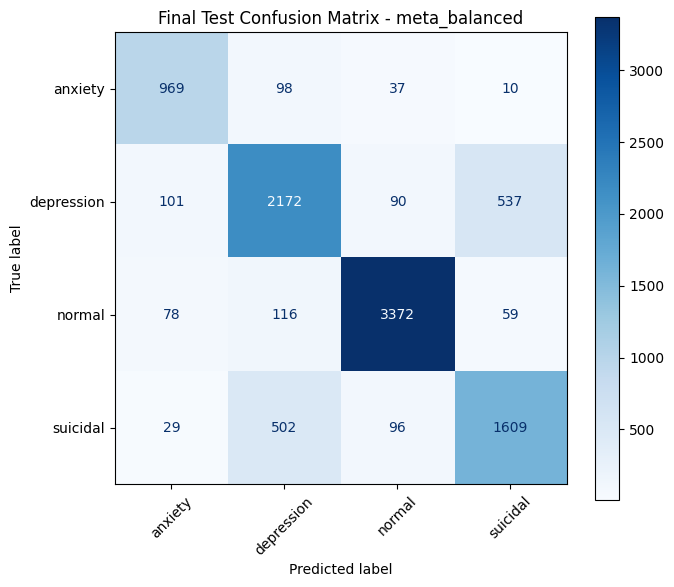

Saved final test confusion matrix: /content/drive/MyDrive/CS114/TeamModel/experiments/tfidf_stack_meta_lr_class_weight_tuning_v1/figures/tfidf_stack_meta_lr_class_weight_tuning_v1__final_test_confusion_matrix.png


In [ ]:
RUN_FINAL_TEST = True

if RUN_FINAL_TEST:
    preds_test_final = predict_with_weights(
        proba_test,
        best_weights,
        class_list
    )

    f1_test = f1_score(
        y_test,
        preds_test_final,
        average="macro"
    )

    acc_test = accuracy_score(
        y_test,
        preds_test_final
    )

    print("\n==================================================")
    print(f"Best Meta Config     : {best_meta_config_name}")
    print(f"Val Macro F1         : {f1_val:.4f}")
    print(f"Final Test Accuracy  : {acc_test:.4f}")
    print(f"Final Test Macro F1  : {f1_test:.4f}")
    print("==================================================")

    print(
        classification_report(
            y_test,
            preds_test_final,
            digits=4,
            zero_division=0
        )
    )

    final_test_report_path = os.path.join(
        REPORT_DIR,
        f"{EXPERIMENT_NAME}__final_test_report.txt"
    )

    with open(final_test_report_path, "w", encoding="utf-8") as f:
        f.write(f"FINAL TEST REPORT - {EXPERIMENT_NAME}\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Best meta config: {best_meta_config_name}\n")
        f.write(f"Best meta class_weight: {best_candidate['meta_class_weight']}\n")
        f.write(f"Val Macro F1 used for selection: {f1_val:.4f}\n")
        f.write(f"Test Accuracy: {acc_test:.4f}\n")
        f.write(f"Test Macro F1: {f1_test:.4f}\n\n")
        f.write(f"Best decision weights: {weight_dict}\n\n")
        f.write(
            classification_report(
                y_test,
                preds_test_final,
                digits=4,
                zero_division=0
            )
        )

    print("Saved final test report:", final_test_report_path)

    cm_test = confusion_matrix(
        y_test,
        preds_test_final,
        labels=class_list
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_test,
        display_labels=class_list
    )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
    plt.title(f"Final Test Confusion Matrix - {best_meta_config_name}")
    plt.tight_layout()

    test_cm_path = os.path.join(
        FIGURE_DIR,
        f"{EXPERIMENT_NAME}__final_test_confusion_matrix.png"
    )

    plt.savefig(test_cm_path, dpi=200)
    plt.show()

    print("Saved final test confusion matrix:", test_cm_path)

else:
    print("RUN_FINAL_TEST = False")
    print("Không đánh giá test trong giai đoạn tuning.")
    print("Chỉ bật RUN_FINAL_TEST=True sau khi đã chọn config bằng validation.")

In [ ]:

import os
import json
import joblib
import numpy as np

PACKAGE_DIR = "/content/drive/MyDrive/CS114/TeamModel/demo_model"
os.makedirs(PACKAGE_DIR, exist_ok=True)

PACKAGE_PATH = os.path.join(
    PACKAGE_DIR,
    "tfidf_stacking_meta_tuned_demo_bundle.joblib"
)


required_vars = [
    "fold_bundles",
    "meta_model",
    "class_list",
    "best_weights",
    "weight_dict",
    "best_meta_config_name",
    "EXPERIMENT_NAME"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Thiếu các biến cần thiết để đóng gói model: {missing_vars}. "
        "Hãy chạy xong phần train/load base models và tune/load meta LR trước."
    )

print("All required variables are available.")


if "best_candidate" in globals() and isinstance(best_candidate, dict):
    best_meta_class_weight = best_candidate.get(
        "meta_class_weight",
        str(getattr(meta_model, "class_weight", None))
    )
else:
    best_meta_class_weight = str(getattr(meta_model, "class_weight", None))

class_list_arr = np.array(class_list)

class_decision_weights_array = np.array(best_weights, dtype=np.float32)

class_decision_weights_array = np.array(
    [
        float(weight_dict[cls])
        for cls in class_list_arr
    ],
    dtype=np.float32
)

print("Class list:", class_list_arr)
print("Decision weights:", class_decision_weights_array)
print("Weight dict:", weight_dict)




demo_bundle = {
    "experiment_name": EXPERIMENT_NAME,


    "fold_bundles": fold_bundles,

    "meta_model": meta_model,

    "class_list": class_list_arr,

    "class_decision_weights": class_decision_weights_array,
    "class_decision_weights_dict": weight_dict,

    "best_meta_config_name": best_meta_config_name,
    "best_meta_class_weight": str(best_meta_class_weight),

    "n_splits": N_SPLITS if "N_SPLITS" in globals() else None,
    "feature_k": FEATURE_K if "FEATURE_K" in globals() else None,
    "word_ngram_range": WORD_NGRAM_RANGE if "WORD_NGRAM_RANGE" in globals() else None,
    "char_analyzer": CHAR_ANALYZER if "CHAR_ANALYZER" in globals() else None,
    "char_ngram_range": CHAR_NGRAM_RANGE if "CHAR_NGRAM_RANGE" in globals() else None,

    "note": (
        "Full TF-IDF stacking model bundle after meta Logistic Regression "
        "class_weight tuning. Includes fold bundles, tuned meta model, "
        "and class decision weights."
    )
}

joblib.dump(demo_bundle, PACKAGE_PATH)

print("\nSaved full tuned demo model bundle:")
print(PACKAGE_PATH)

All required variables are available.
Class list: ['anxiety' 'depression' 'normal' 'suicidal']
Decision weights: [1.   1.4  0.9  1.15]
Weight dict: {'anxiety': 1.0, 'depression': 1.399999976158142, 'normal': 0.8999999761581421, 'suicidal': 1.149999976158142}

Saved full tuned demo model bundle:
/content/drive/MyDrive/CS114/TeamModel/demo_model/tfidf_stacking_meta_tuned_demo_bundle.joblib
